Recrutamento preditivo
A empresa de tecnologia HighTech busca contratar os melhores profissionais do mercado para fazer parte do time e gerar valor para a empresa. A HighTech vem investindo muito nos últimos anos no uso de ciência de dados no setor do RH para trazer ganhos no processo de seleção e recrutamento. O time de ciência de dados junto com o time de RH vem realizando juntos um projeto de recrutamento preditivo.

O recrutamento preditivo é uma técnica de People Analytics para encontrar os melhores candidatos para contratação da empresa, na prática, o recrutamento preditivo aumenta as chances do recrutador potencializar o processo de seleção. Por meio da coleta e análise de dados, é possível avaliar o perfil e o fit cultural dos profissionais para entender se existe uma boa aderência à vaga.

Problema de negócio:

O objetivo da HighTech é identificar quais são os melhores indicadores para realizar o recrutamento de profissionais.

Base de dados

Este conjunto de dados consiste em algumas características como: percentual de ensino médio e superior e especialização, experiência de trabalho e ofertas salariais para os profissionais colocados.

Desafio

Você como cientista de dados do time de dados da HighTech tem o desafio de criar um modelo preditivo de recrutamento para prever como e quais são as melhores variáveis que podem colocar um profissional bem qualificado na HighTech.

In [98]:
import pandas as pd
dados = pd.read_excel("Recrutamento.xlsx")

In [99]:
dados.shape

(215, 15)

In [100]:
dados.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Yes,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Yes,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Yes,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,No,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Yes,425000.0


In [101]:
dados.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
sl_no,215.0,108.00,62.21,1.00,54.50,108.0,161.50,215.00
ssc_p,215.0,67.30,10.83,40.89,60.60,67.0,75.70,89.40
hsc_p,215.0,66.33,10.90,37.00,60.90,65.0,73.00,97.70
degree_p,215.0,66.37,7.36,50.00,61.00,66.0,72.00,91.00
etest_p,215.0,72.10,13.28,50.00,60.00,71.0,83.50,98.00
mba_p,215.0,62.28,5.83,51.21,57.94,62.0,66.26,77.89
salary,148.0,288655.41,93457.45,200000.00,240000.00,265000.0,300000.00,940000.00


In [102]:
set(dados.status) # verificando o tipo de dado dentro da coluna

{'No', 'Yes'}

In [103]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    str    
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    str    
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    str    
 6   hsc_s           215 non-null    str    
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    str    
 9   workex          215 non-null    str    
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    str    
 12  mba_p           215 non-null    float64
 13  status          215 non-null    str    
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), str(8)
memory usage: 25.3 KB


In [104]:
dados.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

<Axes: >

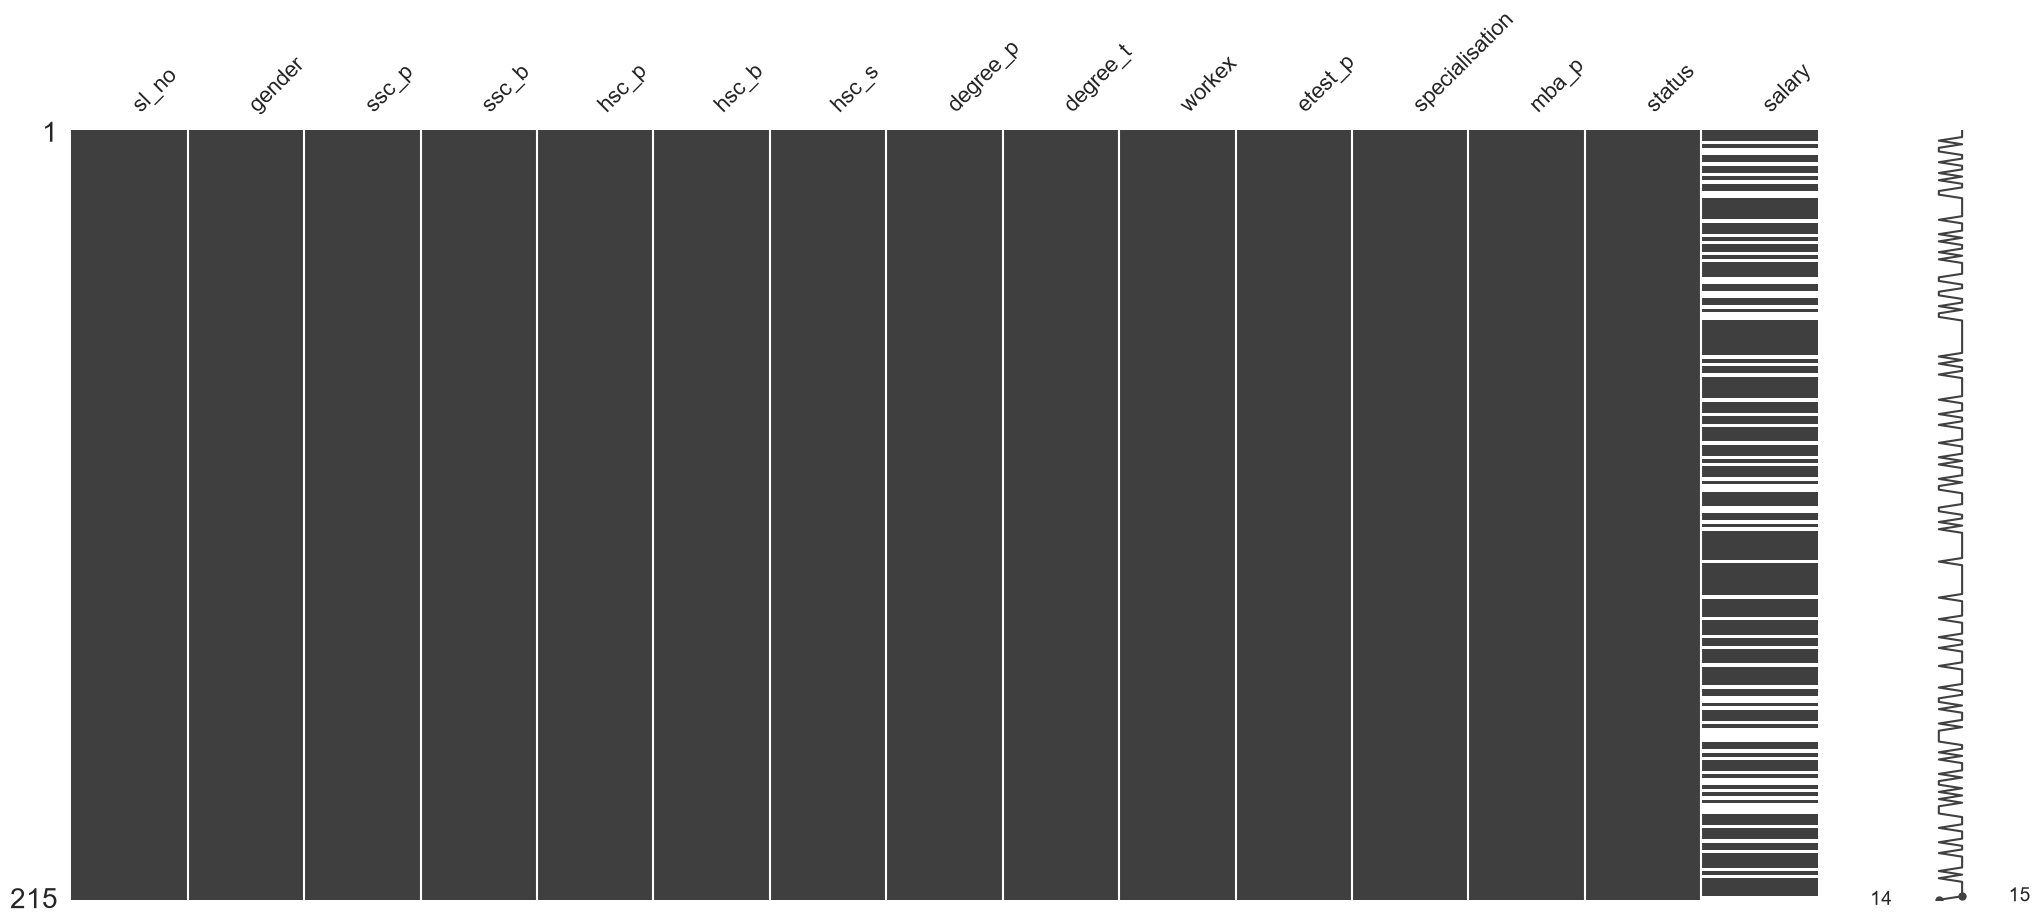

In [105]:
#Validando espaços em branco é uma biblioteca do pandas

import missingno as msno
msno.matrix(dados)

<Axes: xlabel='status', ylabel='salary'>

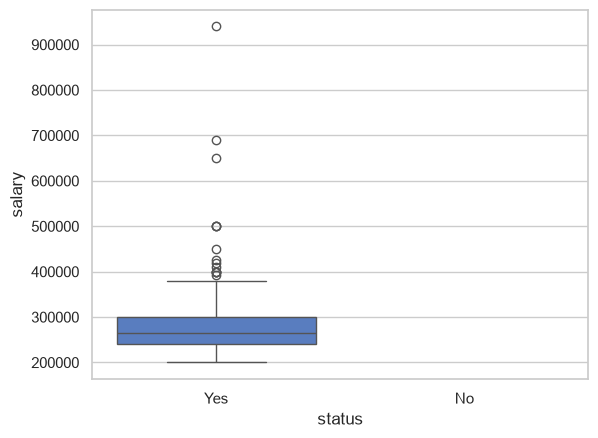

In [106]:
import seaborn as sb
sb.boxplot(x = "status", y = "salary", data = dados)


In [107]:
dados.loc[:, 'salary'] = dados['salary'].fillna(value=0)

In [108]:
dados.isnull().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

<Axes: xlabel='hsc_p'>

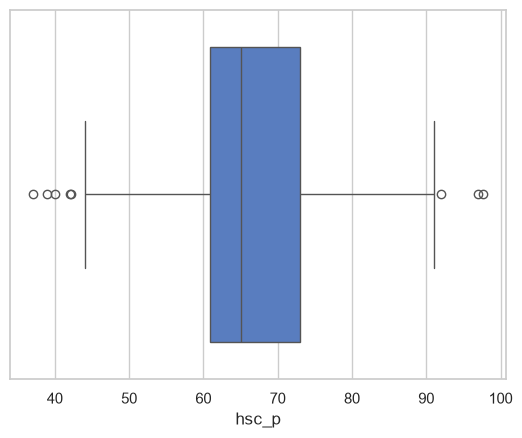

In [109]:
sb.boxplot(x=dados["hsc_p"])

<Axes: xlabel='hsc_p', ylabel='Count'>

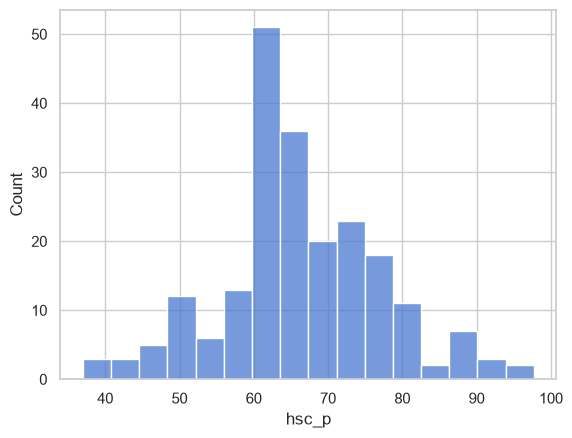

In [110]:
sb.histplot(data = dados, x = "hsc_p")

<Axes: xlabel='degree_p'>

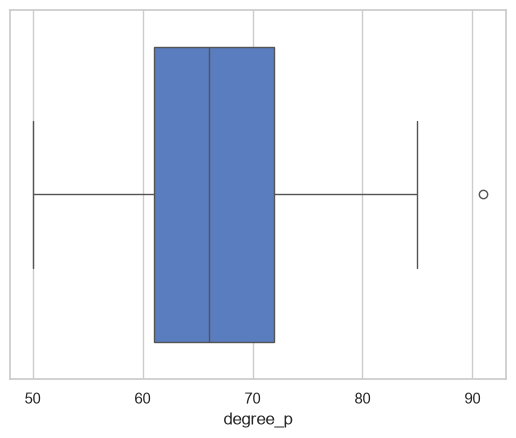

In [111]:
sb.boxplot( data = dados, x = dados['degree_p'])

<Axes: xlabel='degree_p', ylabel='Count'>

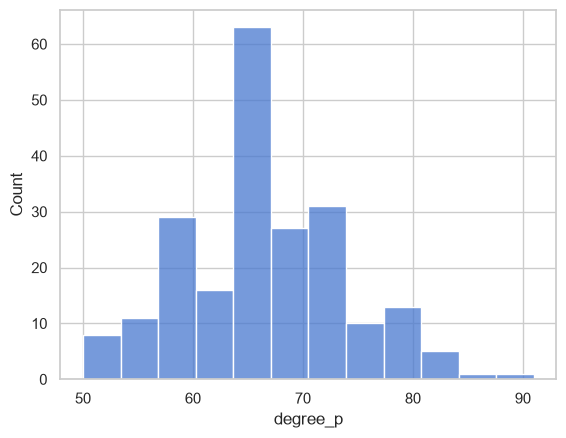

In [112]:
sb.histplot(x ="degree_p", data = dados)

<Axes: xlabel='etest_p'>

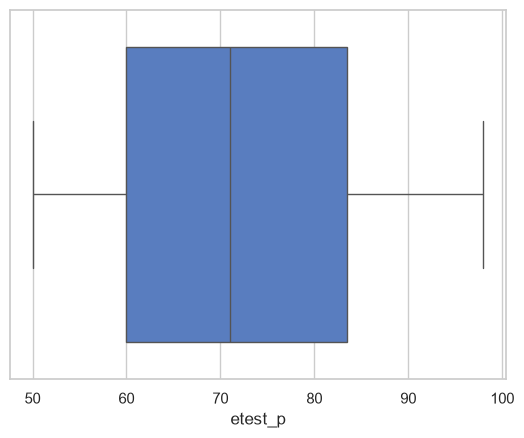

In [113]:
sb.boxplot(x = dados["etest_p"])

<Axes: xlabel='mba_p'>

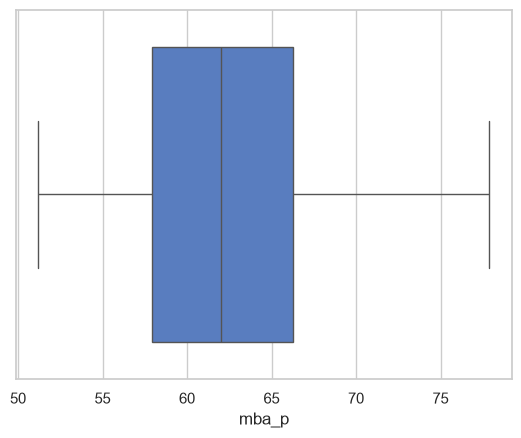

In [114]:
sb.boxplot(x = dados["mba_p"])

<Axes: xlabel='salary'>

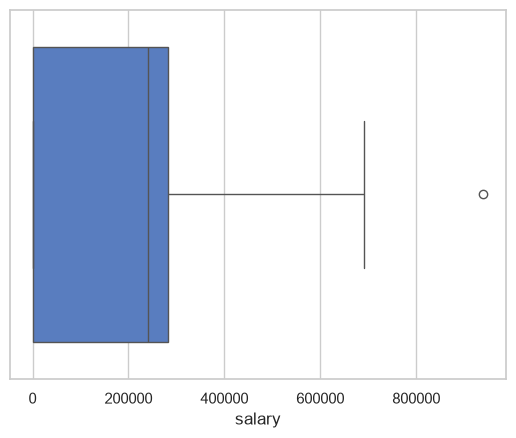

In [115]:
sb.boxplot(x = dados["salary"])

<Axes: xlabel='salary', ylabel='Count'>

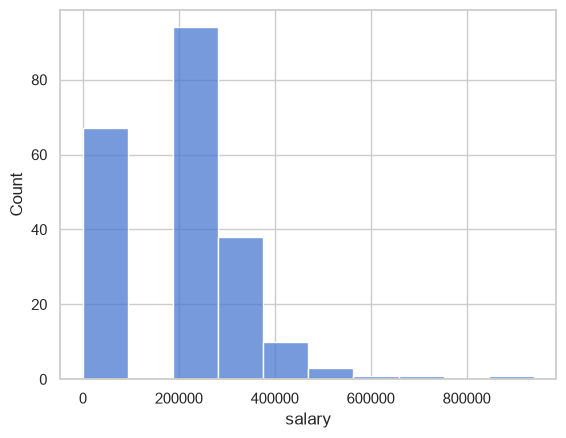

In [116]:
sb.histplot( x ="salary", data = dados)

[Text(36.65625, 0.5, ' mba_p')]

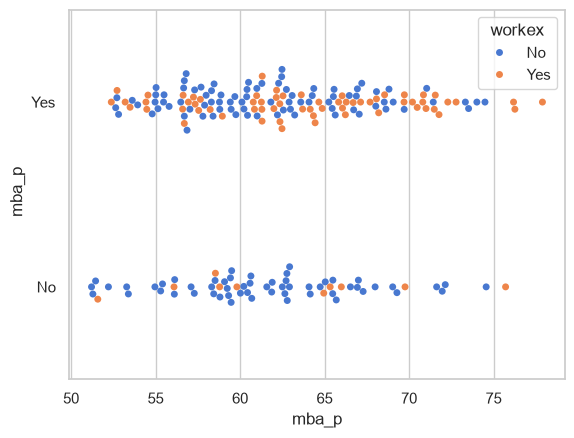

In [117]:
sb.set_theme(style = "whitegrid", palette = "muted")
ax = sb.swarmplot(data = dados, x='mba_p', y = 'status', hue = "workex")
ax.set(ylabel = " mba_p" )

In [118]:
import plotly.express as px

px.violin(dados, y="salary", x="specialisation", color="gender", box=True, points="all")

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'alignmentgroup': 'True',
              'box': {'visible': True},
              'hovertemplate': 'gender=M<br>specialisation=%{x}<br>salary=%{y}<extra></extra>',
              'legendgroup': 'M',
              'marker': {'color': '#636efa'},
              'name': 'M',
              'offsetgroup': 'M',
              'orientation': 'v',
              'points': 'all',
              'scalegroup': 'True',
              'showlegend': True,
              'type': 'violin',
              'x': array(['Mkt&HR', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&HR', 'Mkt&Fin', 'Mkt&Fin',
                          'Mkt&Fin', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&HR', 'Mkt&Fin', 'Mkt&HR',
                          'Mkt&Fin', 'Mkt&Fin', 'Mkt&HR', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&HR',
                          'Mkt&Fin', 'Mkt&Fin', 'Mkt&HR', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&Fin',
                          'Mkt&HR', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&HR', 'Mkt&HR', 'Mkt&HR', 'Mkt&Fin',
                          'Mkt&Fin', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&HR',
                          'Mkt&Fin', 'Mkt&HR', 'Mkt&HR', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&Fin',
                          'Mkt&Fin', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&Fin',
                          'Mkt&Fin', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&HR',
                          'Mkt&HR', 'Mkt&HR', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&HR', 'Mkt&HR',
                          'Mkt&HR', 'Mkt&HR', 'Mkt&Fin', 'Mkt&HR', 'Mkt&Fin', 'Mkt&HR', 'Mkt&HR',
                          'Mkt&HR', 'Mkt&HR', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&HR', 'Mkt&Fin', 'Mkt&HR',
                          'Mkt&HR', 'Mkt&HR', 'Mkt&HR', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&HR', 'Mkt&HR',
                          'Mkt&HR', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&HR', 'Mkt&Fin', 'Mkt&Fin',
                          'Mkt&Fin', 'Mkt&HR', 'Mkt&HR', 'Mkt&Fin', 'Mkt&HR', 'Mkt&Fin',
                          'Mkt&Fin', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&HR', 'Mkt&HR', 'Mkt&Fin',
                          'Mkt&Fin', 'Mkt&HR', 'Mkt&HR', 'Mkt&HR', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&HR',
                          'Mkt&Fin', 'Mkt&HR', 'Mkt&Fin', 'Mkt&HR', 'Mkt&Fin', 'Mkt&HR', 'Mkt&HR',
                          'Mkt&Fin', 'Mkt&HR', 'Mkt&Fin', 'Mkt&HR', 'Mkt&Fin', 'Mkt&Fin',
                          'Mkt&Fin', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&HR', 'Mkt&Fin', 'Mkt&HR',
                          'Mkt&Fin', 'Mkt&HR', 'Mkt&HR', 'Mkt&HR', 'Mkt&Fin', 'Mkt&Fin',
                          'Mkt&Fin', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&HR'],
                         dtype=object),
              'x0': ' ',
              'xaxis': 'x',
              'y': {'bdata': ('AAAAAMB6EEEAAAAAAGoIQQAAAACAhA' ... 'AA4MgQQQAAAABgARJBAAAAAAAAAAA='),
                    'dtype': 'f8'},
              'y0': ' ',
              'yaxis': 'y'},
             {'alignmentgroup': 'True',
              'box': {'visible': True},
              'hovertemplate': 'gender=F<br>specialisation=%{x}<br>salary=%{y}<extra></extra>',
              'legendgroup': 'F',
              'marker': {'color': '#EF553B'},
              'name': 'F',
              'offsetgroup': 'F',
              'orientation': 'v',
              'points': 'all',
              'scalegroup': 'True',
              'showlegend': True,
              'type': 'violin',
              'x': array(['Mkt&Fin', 'Mkt&HR', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&HR',
                          'Mkt&Fin', 'Mkt&HR', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&HR', 'Mkt&HR', 'Mkt&HR',
                          'Mkt&Fin', 'Mkt&HR', 'Mkt&HR', 'Mkt&HR', 'Mkt&Fin', 'Mkt&HR', 'Mkt&Fin',
                          'Mkt&HR', 'Mkt&HR', 'Mkt&HR', 'Mkt&HR', 'Mkt&HR', 'Mkt&HR', 'Mkt&Fin',
                          'Mkt&HR', 'Mkt&HR', 'Mkt&Fin', 'Mkt&HR', 'Mkt&HR', 'Mkt&Fin', 'Mkt&HR',
                          'Mkt&HR', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&Fin',
                          'Mkt&HR', 'Mkt&Fin', 'Mkt&HR', 'Mkt&Fin', 'Mkt&Fin', 'Mkt&HR',
                          'Mk

Inferência sobre os dados:

Os maiores salários foram dados aos homens.
O salário médio oferecido também foi maior para homens.

Vamos analisar a correlação entre as pontuações de desempenho acadêmico com a contratação:

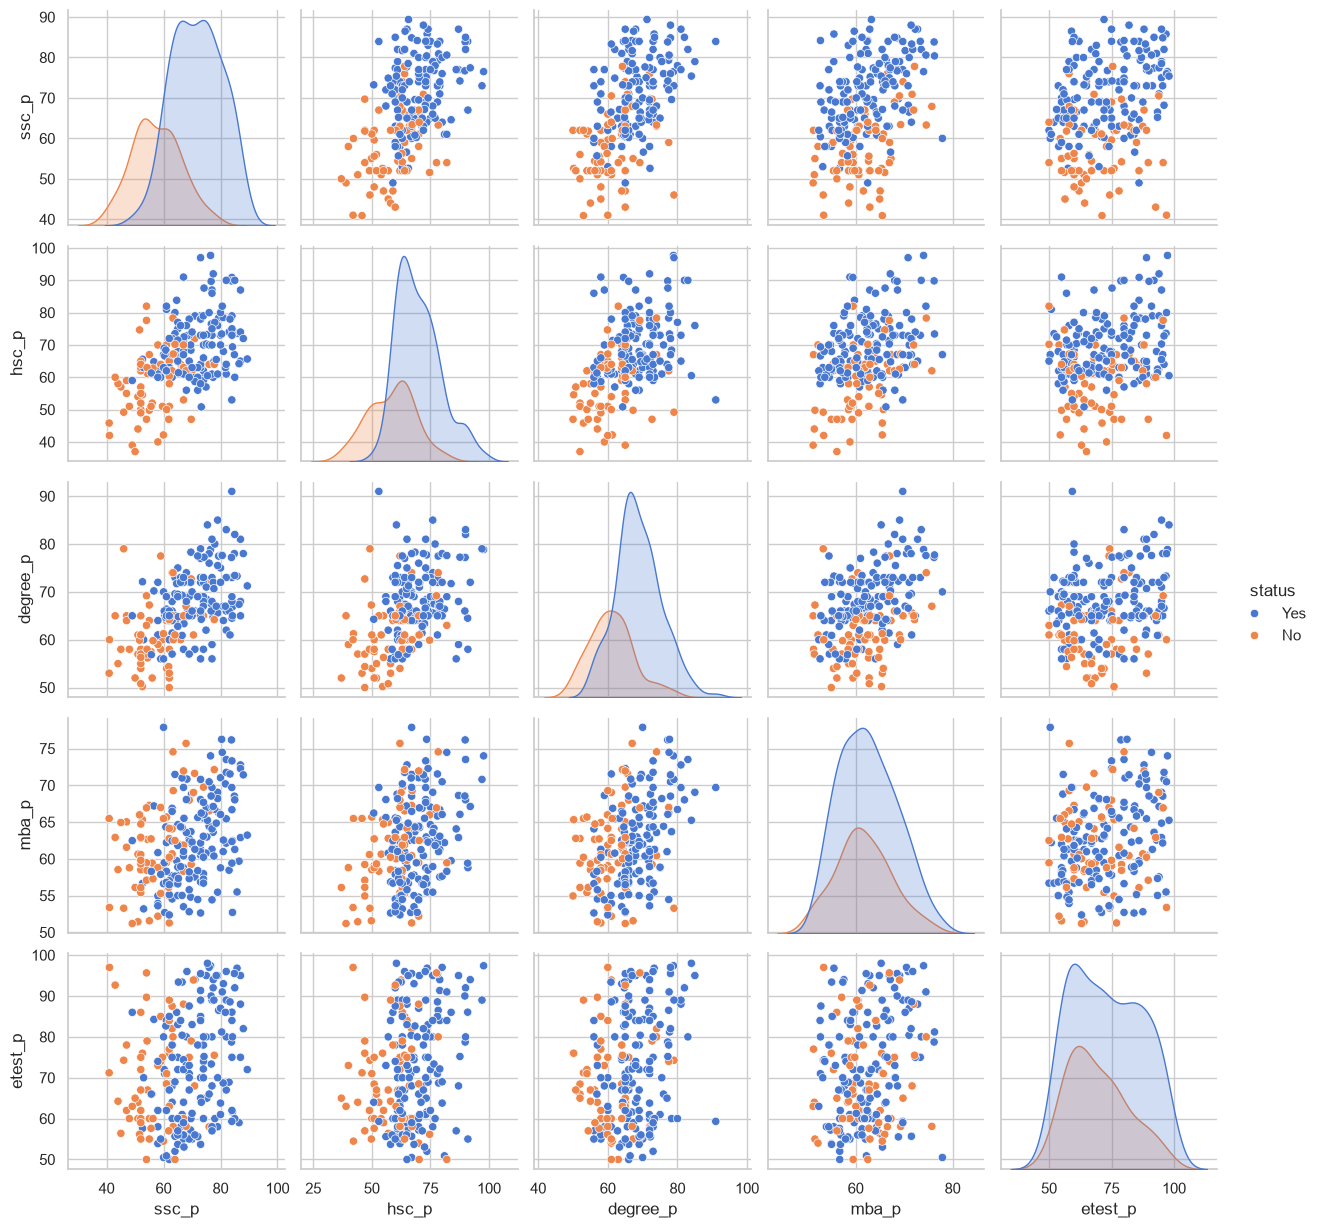

In [ ]:
sb.pairplot(dados,vars=['ssc_p','hsc_p','degree_p','mba_p','etest_p'],hue="status")

In [ ]:
import matplotlib.pyplot as plt


<Axes: >

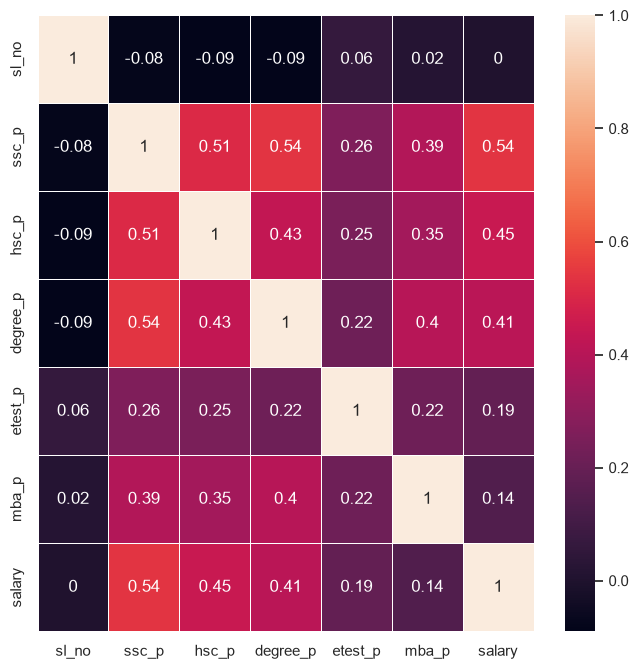

In [ ]:
correlation_matrix = dados.select_dtypes(include=['number']).corr().round(2)
fig, ax = plt.subplots(figsize=(8,8))
sb.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax)

#correlação com variavies númericas apenas

In [ ]:
#label enconder ---Transformando variáveis categorigas em numéricas
from sklearn.preprocessing import LabelEncoder

colunas = ["gender", "workex", "specialisation", "status"]

label_enconder = LabelEncoder()

for col in colunas:
    dados[col] = label_enconder.fit_transform(dados[col])
    dados.head()

In [ ]:
dummy_hsc_s=pd.get_dummies(dados['hsc_s'], prefix='dummy',dtype=int)
dummy_degree_t=pd.get_dummies(dados['degree_t'], prefix='dummy', dtype=int)

dados_dummy = pd.concat([dados,dummy_hsc_s,dummy_degree_t],axis=1)
dados_dummy.drop(['hsc_s','degree_t','salary'],axis=1, inplace=True)
dados_dummy.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,degree_p,workex,etest_p,specialisation,mba_p,status,dummy_Arts,dummy_Commerce,dummy_Science,dummy_Comm&Mgmt,dummy_Others,dummy_Sci&Tech
0,1,1,67.00,Others,91.00,Others,58.00,0,55.0,1,58.80,1,0,1,0,0,0,1
1,2,1,79.33,Central,78.33,Others,77.48,1,86.5,0,66.28,1,0,0,1,0,0,1
2,3,1,65.00,Central,68.00,Central,64.00,0,75.0,0,57.80,1,1,0,0,1,0,0
3,4,1,56.00,Central,52.00,Central,52.00,0,66.0,1,59.43,0,0,0,1,0,0,1
4,5,1,85.80,Central,73.60,Central,73.30,0,96.8,0,55.50,1,0,1,0,1,0,0


<Axes: >

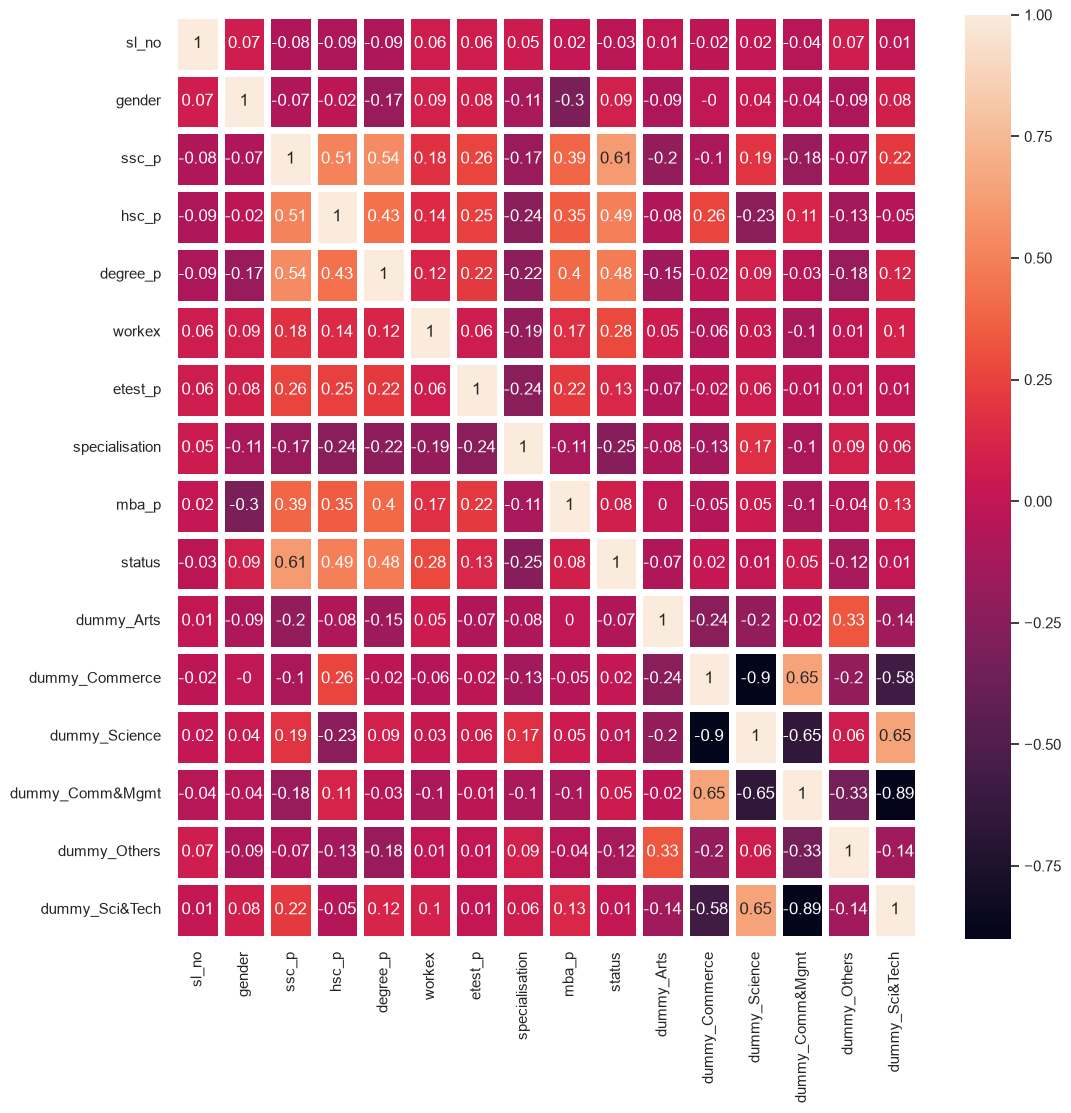

In [ ]:
correlation_matrix = dados_dummy.select_dtypes(include=['number']).corr().round(2)

fig, ax = plt.subplots(figsize = (12,12))

sb.heatmap(data = correlation_matrix, annot = True, linewidths=5, ax = ax)

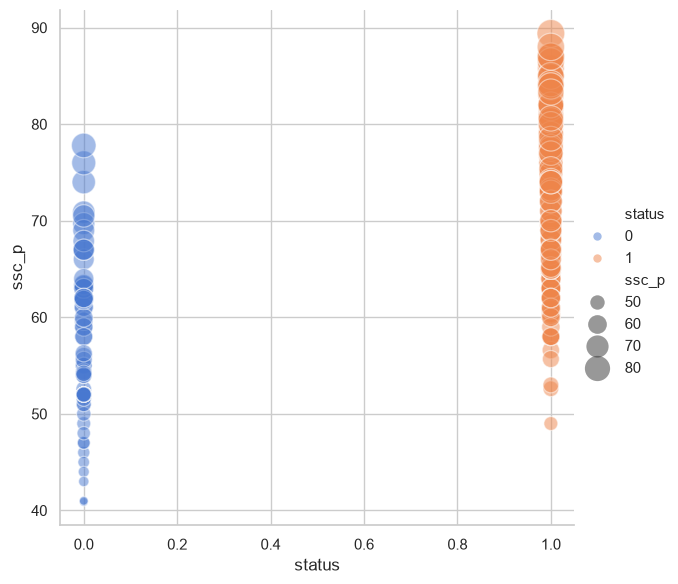

In [ ]:
sb.relplot(x="status", y="ssc_p", hue="status", size="ssc_p",
            sizes=(40, 400), alpha=.5, palette="muted",
            height=6, data=dados_dummy)

In [ ]:
x = dados_dummy[["ssc_p", "hsc_p",'degree_p', "workex", "mba_p"]]
y = dados_dummy["status"]

In [119]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [120]:
x_teste, x_train, y_test, y_train = train_test_split(x, y, test_size = 0.2, random_state=7, stratify=y)

In [121]:
#PADRONIZAR OS DADOS
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()
scaler.fit(x_train)

x_train_escalonado = scaler.transform(x_train)
x_test_escalonado = scaler.transform(x_teste)


In [122]:
import numpy as np

In [158]:
error = []

# Calculating error for K values between 1 and 10
for i in range(1, 10): #range de tentativas para k
    knn = KNeighborsClassifier(n_neighbors=i)# aqui definimos  o k
    knn.fit(x_train_escalonado, y_train) #treinando o algoritmo para encontrar o erro
    pred_i = knn.predict(x_test_escalonado) #armazenando as previsões
    error.append(np.mean(pred_i != y_test)) #armazenando o valor do erro médio na lista de erros


Text(0, 0.5, 'Mean Error')

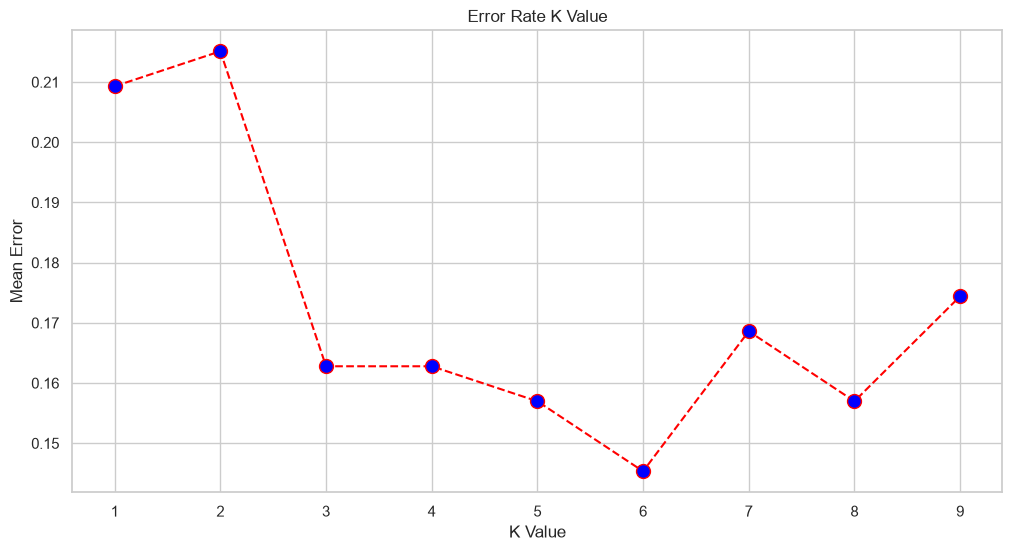

In [163]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, 10), error, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Error Rate K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')

In [142]:
modelo_classificador = KNeighborsClassifier(n_neighbors=6)

modelo_classificador.fit(x_train_escalonado, y_train)

y_predito = modelo_classificador.predict(x_test_escalonado)

In [143]:
y_predito

array([0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1])

In [144]:
from sklearn.metrics import accuracy_score


In [150]:
y_test

136    0
97     0
211    1
21     1
144    0
      ..
194    0
54     1
92     1
51     0
47     1
Name: status, Length: 172, dtype: int64

In [149]:
print(accuracy_score(y_test,y_predito))

0.8546511627906976


In [145]:
#SVN = SUPORTE VECTOR MACHINE

from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

In [146]:
svm = Pipeline(
    [
        ("linear_svc", LinearSVC(C=1))
    ]
)

In [131]:
svm.fit(x_train_escalonado, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('linear_svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [132]:
y_predito_svm = svm.predict(x_test_escalonado)

In [133]:
print(accuracy_score(y_test, y_predito_svm))

0.8546511627906976


In [164]:

from sklearn import metrics
from sklearn.metrics import roc_curve, auc

In [165]:
y_prob = modelo_classificador.predict_proba(x_test_escalonado)[:,1] 

In [166]:

false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(false_positive_rate, true_positive_rate)
roc_auc

0.8973634651600753

Text(0.5, 0, 'False Positive Rate')

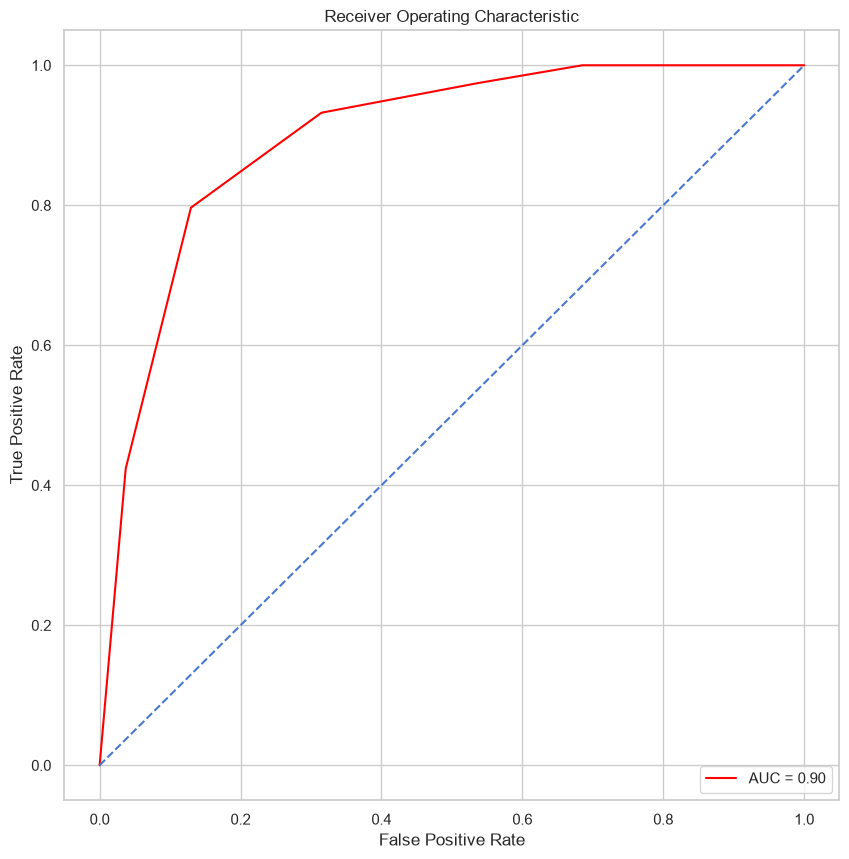

In [167]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.title('Receiver Operating Characteristic')
plt.plot(false_positive_rate,true_positive_rate, color='red',label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')